In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Cấu hình hiển thị đồ thị
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (14, 6)


In [2]:
DATA_DIR_MOTION_SENSE = Path("../../data/raw/motion_sense")
print(f"Kiểm tra thư mục dữ liệu: {DATA_DIR_MOTION_SENSE.exists()}")

Kiểm tra thư mục dữ liệu: True


=== 5 DÒNG ĐẦU FILE DATA_SUBJECTS_INFO.CSV ===


,code,weight,height,age,gender
0,1,102,188,46,1
1,2,72,180,28,1
2,3,48,161,28,0
3,4,90,176,31,1
4,5,48,164,23,0



=== THỐNG KÊ TỔNG QUAN ===
Tổng số người tham gia: 24 (Mã ID từ 1 đến 24)


/tmp/ipykernel_14449/764101726.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_subjects, x="gender", ax=axes[0], palette="Set2")


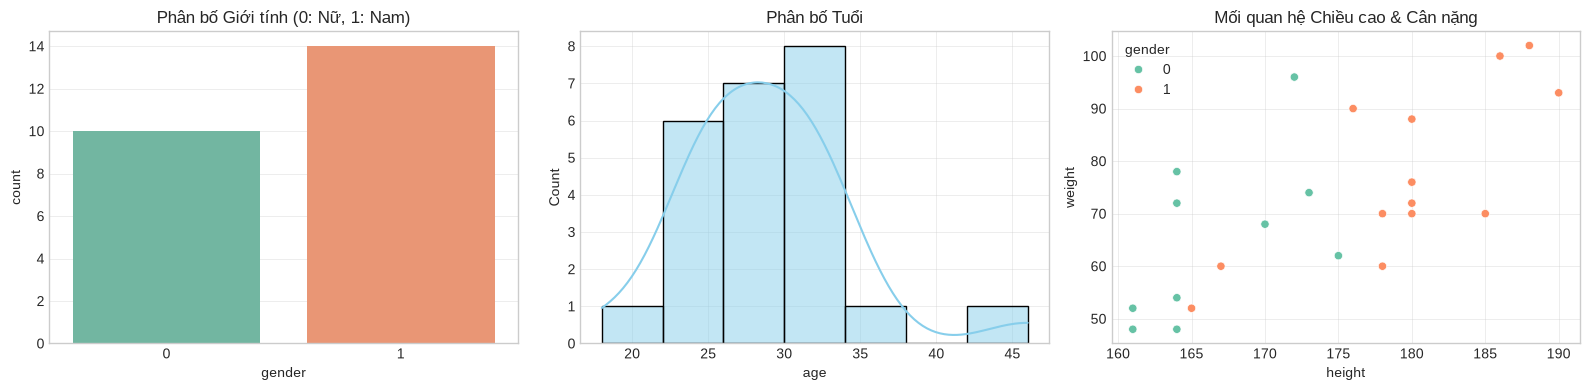

In [3]:
# Đọc file thông tin người dùng
df_subjects = pd.read_csv(DATA_DIR_MOTION_SENSE / "data_subjects_info.csv")

if "Unnamed: 0" in df_subjects.columns:
    df_subjects = df_subjects.drop(columns=["Unnamed: 0"])

print("=== 5 DÒNG ĐẦU FILE DATA_SUBJECTS_INFO.CSV ===")
display(df_subjects.head())

print("\n=== THỐNG KÊ TỔNG QUAN ===")
print(
    f"Tổng số người tham gia: {len(df_subjects)} (Mã ID từ {df_subjects['code'].min()} đến {df_subjects['code'].max()})"
)

# Trực quan hóa phân bố Nam/Nữ, Chiều cao, Cân nặng
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_subjects, x="gender", ax=axes[0], palette="Set2")
axes[0].set_title("Phân bố Giới tính (0: Nữ, 1: Nam)")

sns.histplot(data=df_subjects, x="age", kde=True, ax=axes[1], color="skyblue")
axes[1].set_title("Phân bố Tuổi")

sns.scatterplot(
    data=df_subjects,
    x="height",
    y="weight",
    hue="gender",
    ax=axes[2],
    palette="Set2",
)
axes[2].set_title("Mối quan hệ Chiều cao & Cân nặng")

plt.tight_layout()
plt.show()

# Kiểm tra cấu trúc 1 file dữ liệu cảm biến & Xác minh tần số $50\text{ Hz}$

In [4]:
sample_path = DATA_DIR_MOTION_SENSE/"wlk_7"/"sub_1.csv"
df_sample = pd.read_csv(sample_path)

In [5]:
print(df_sample.info())
# print(df_sample.head())

<class 'pandas.DataFrame'>
RangeIndex: 5439 entries, 0 to 5438
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5439 non-null   int64  
 1   attitude.roll       5439 non-null   float64
 2   attitude.pitch      5439 non-null   float64
 3   attitude.yaw        5439 non-null   float64
 4   gravity.x           5439 non-null   float64
 5   gravity.y           5439 non-null   float64
 6   gravity.z           5439 non-null   float64
 7   rotationRate.x      5439 non-null   float64
 8   rotationRate.y      5439 non-null   float64
 9   rotationRate.z      5439 non-null   float64
 10  userAcceleration.x  5439 non-null   float64
 11  userAcceleration.y  5439 non-null   float64
 12  userAcceleration.z  5439 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 552.5 KB
None


In [6]:
if "Unnamed: 0" in df_sample.columns:
    df_sample = df_sample.drop(columns = ["Unnamed: 0"])

In [7]:
print(df_sample.info())

<class 'pandas.DataFrame'>
RangeIndex: 5439 entries, 0 to 5438
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   attitude.roll       5439 non-null   float64
 1   attitude.pitch      5439 non-null   float64
 2   attitude.yaw        5439 non-null   float64
 3   gravity.x           5439 non-null   float64
 4   gravity.y           5439 non-null   float64
 5   gravity.z           5439 non-null   float64
 6   rotationRate.x      5439 non-null   float64
 7   rotationRate.y      5439 non-null   float64
 8   rotationRate.z      5439 non-null   float64
 9   userAcceleration.x  5439 non-null   float64
 10  userAcceleration.y  5439 non-null   float64
 11  userAcceleration.z  5439 non-null   float64
dtypes: float64(12)
memory usage: 510.0 KB
None


# Trực quan hóa sóng tín hiệu cảm biến (12 kênh)

In [8]:
# Tạo danh sách các nhóm kênh
attitude_cols = ["attitude.roll", "attitude.pitch", "attitude.yaw"]
gravity_cols = ["gravity.x", "gravity.y", "gravity.z"]
rotation_cols = ["rotationRate.x", "rotationRate.y", "rotationRate.z"]
user_acc_cols = ["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]

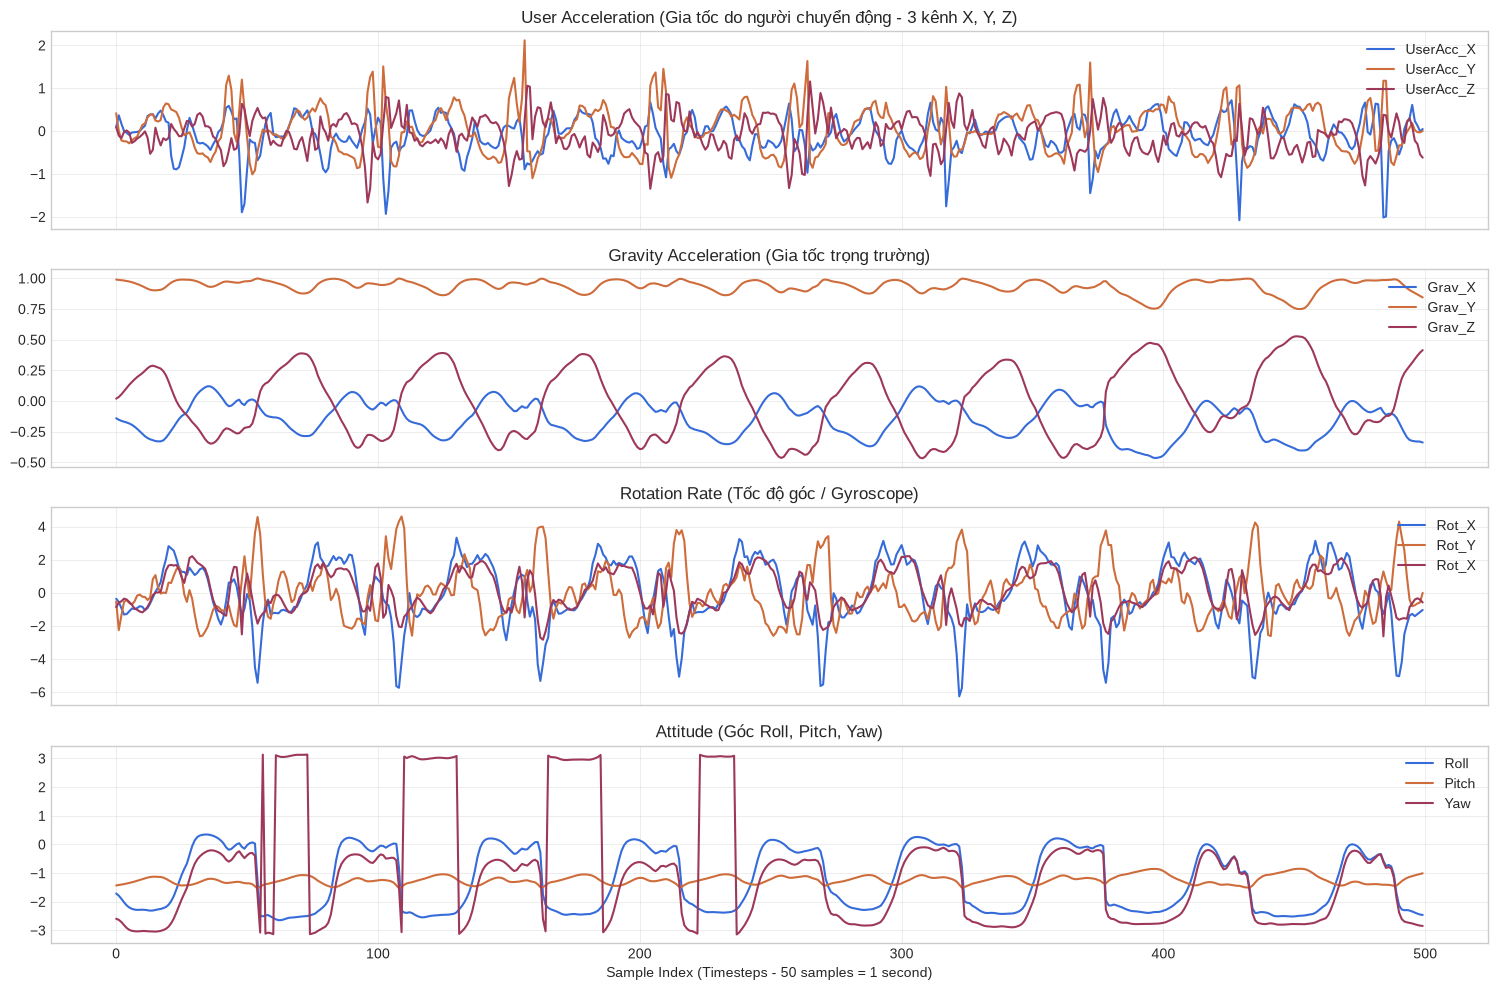

In [9]:
# Vẽ đồ thị 4 nhóm cảm biến trong 500 timesteps đầu tiên (10 giây)
fig, axes = plt.subplots( #vẽ các biểu đồ (axes) lên 1 khung hình
    4, # số hàng
    1, # số cột
    figsize = (15,10), # rộng = 15, cao = 10
    sharex = True # các biều đồ có cùng kích thước ( 4 hàng, 1 cột, mỗi hàng 1 biều đồ và có cùng kích thước)
    # fig là toàn bộ giấy vẽ, axes là 4 mảnh vẽ lên fig
)

# 1. User Acceleration (Gia tốc người dùng - 3 kênh cốt lõi ta sẽ dùng)
axes[0].plot(df_sample[user_acc_cols][:500])
axes[0].set_title(
    "User Acceleration (Gia tốc do người chuyển động - 3 kênh X, Y, Z)"
)
axes[0].legend(["UserAcc_X","UserAcc_Y","UserAcc_Z"],loc = "upper right")

# 2. Gravity (Gia tốc trọng trường)
axes[1].plot(df_sample[gravity_cols][:500])
axes[1].set_title(
    "Gravity Acceleration (Gia tốc trọng trường)"
)
axes[1].legend(["Grav_X","Grav_Y","Grav_Z"],loc = "upper right")

# 3. Rotation Rate (Con quay hồi chuyển / Gyroscope)
axes[2].plot(df_sample[rotation_cols][:500])
axes[2].set_title(
    "Rotation Rate (Tốc độ góc / Gyroscope)"
)
axes[2].legend(["Rot_X","Rot_Y","Rot_X"],loc = "upper right")

# 4. Attitude (Góc định hướng)
axes[3].plot(df_sample[attitude_cols][:500])
axes[3].set_title(
    "Attitude (Góc Roll, Pitch, Yaw)"
)
axes[3].legend(["Roll", "Pitch", "Yaw"],loc = "upper right")

plt.xlabel("Sample Index (Timesteps - 50 samples = 1 second)")
plt.tight_layout()
plt.show()


# So sánh dạng sóng Gia tốc (userAcceleration) giữa các Hoạt động

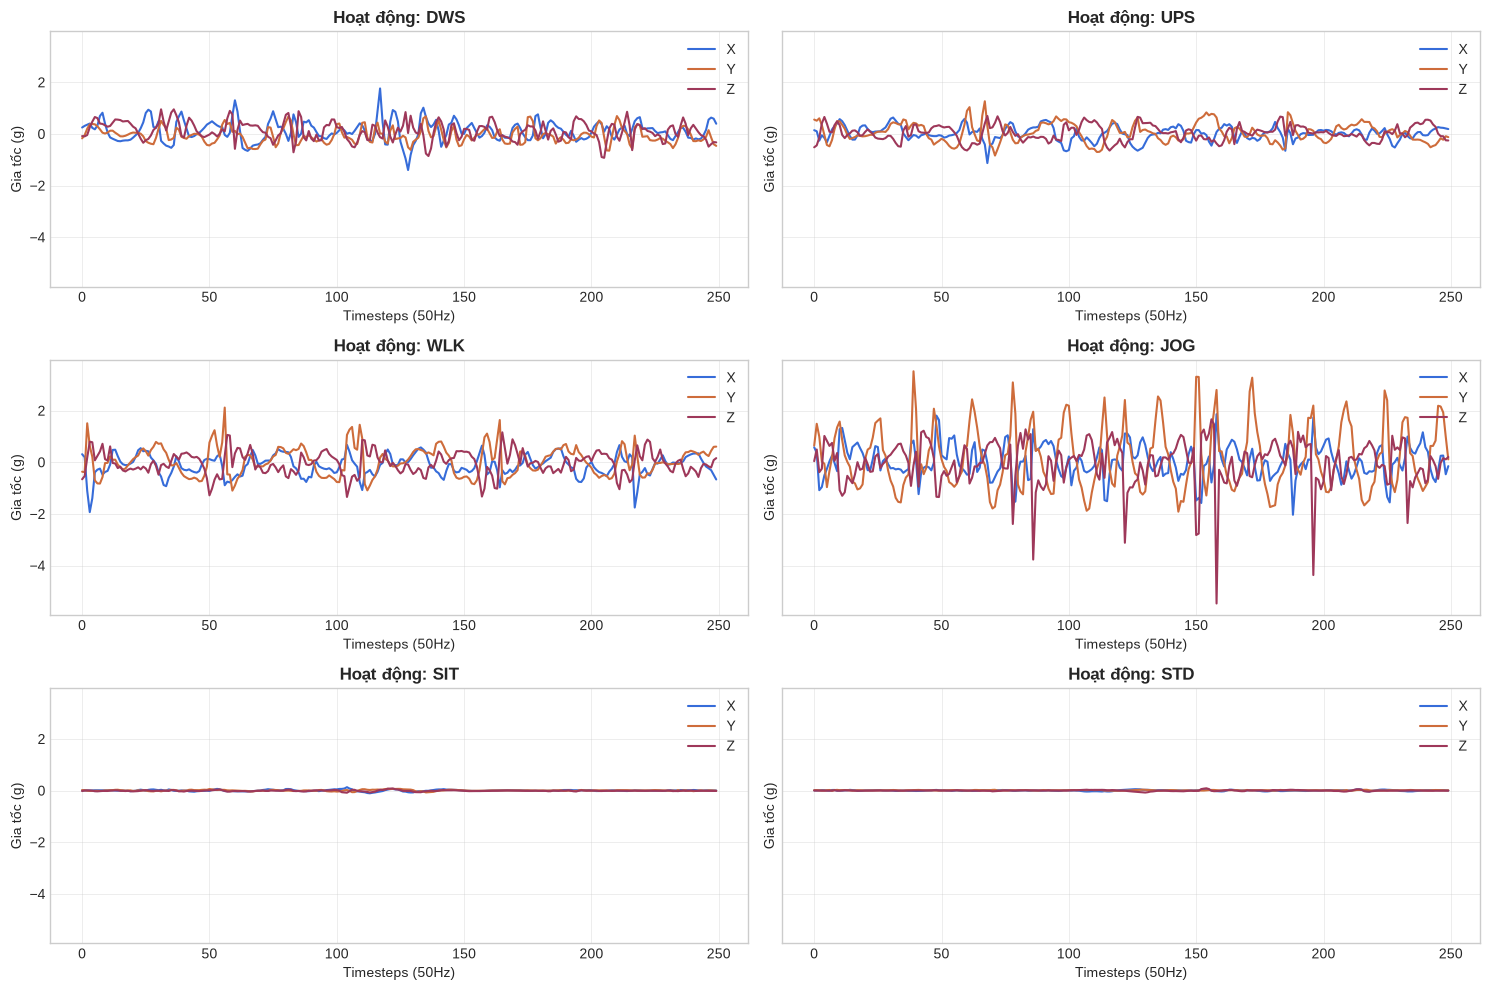

In [11]:
# Định nghĩa các thư mục đại diện cho 6 hoạt động
activities = {
    "dws": "dws_1/sub_1.csv",  # Đi xuống cầu thang
    "ups": "ups_3/sub_1.csv",  # Đi lên cầu thang
    "wlk": "wlk_7/sub_1.csv",  # Đi bộ
    "jog": "jog_9/sub_1.csv",  # Chạy bộ
    "sit": "sit_5/sub_1.csv",  # Ngồi
    "std": "std_6/sub_1.csv",  # Đứng
}

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for idx, (act_code, rel_path) in enumerate(activities.items()):
    file_path = DATA_DIR_MOTION_SENSE / rel_path
    if file_path.exists():
        df_act = pd.read_csv(file_path)
        # Lấy 250 timesteps (5 giây) của 3 trục gia tốc
        acc_data = df_act[
            [
                "userAcceleration.x",
                "userAcceleration.y",
                "userAcceleration.z",
            ]
        ].iloc[100:350]

        axes[idx].plot(acc_data.values)
        axes[idx].set_title(f"Hoạt động: {act_code.upper()}", fontsize=12, fontweight="bold")

        axes[idx].set_xlabel("Timesteps (50Hz)")
        axes[idx].set_ylabel("Gia tốc (g)")
        axes[idx].grid(True)
        axes[idx].legend(["X","Y","Z"],loc = "upper right")

plt.tight_layout()
plt.show()

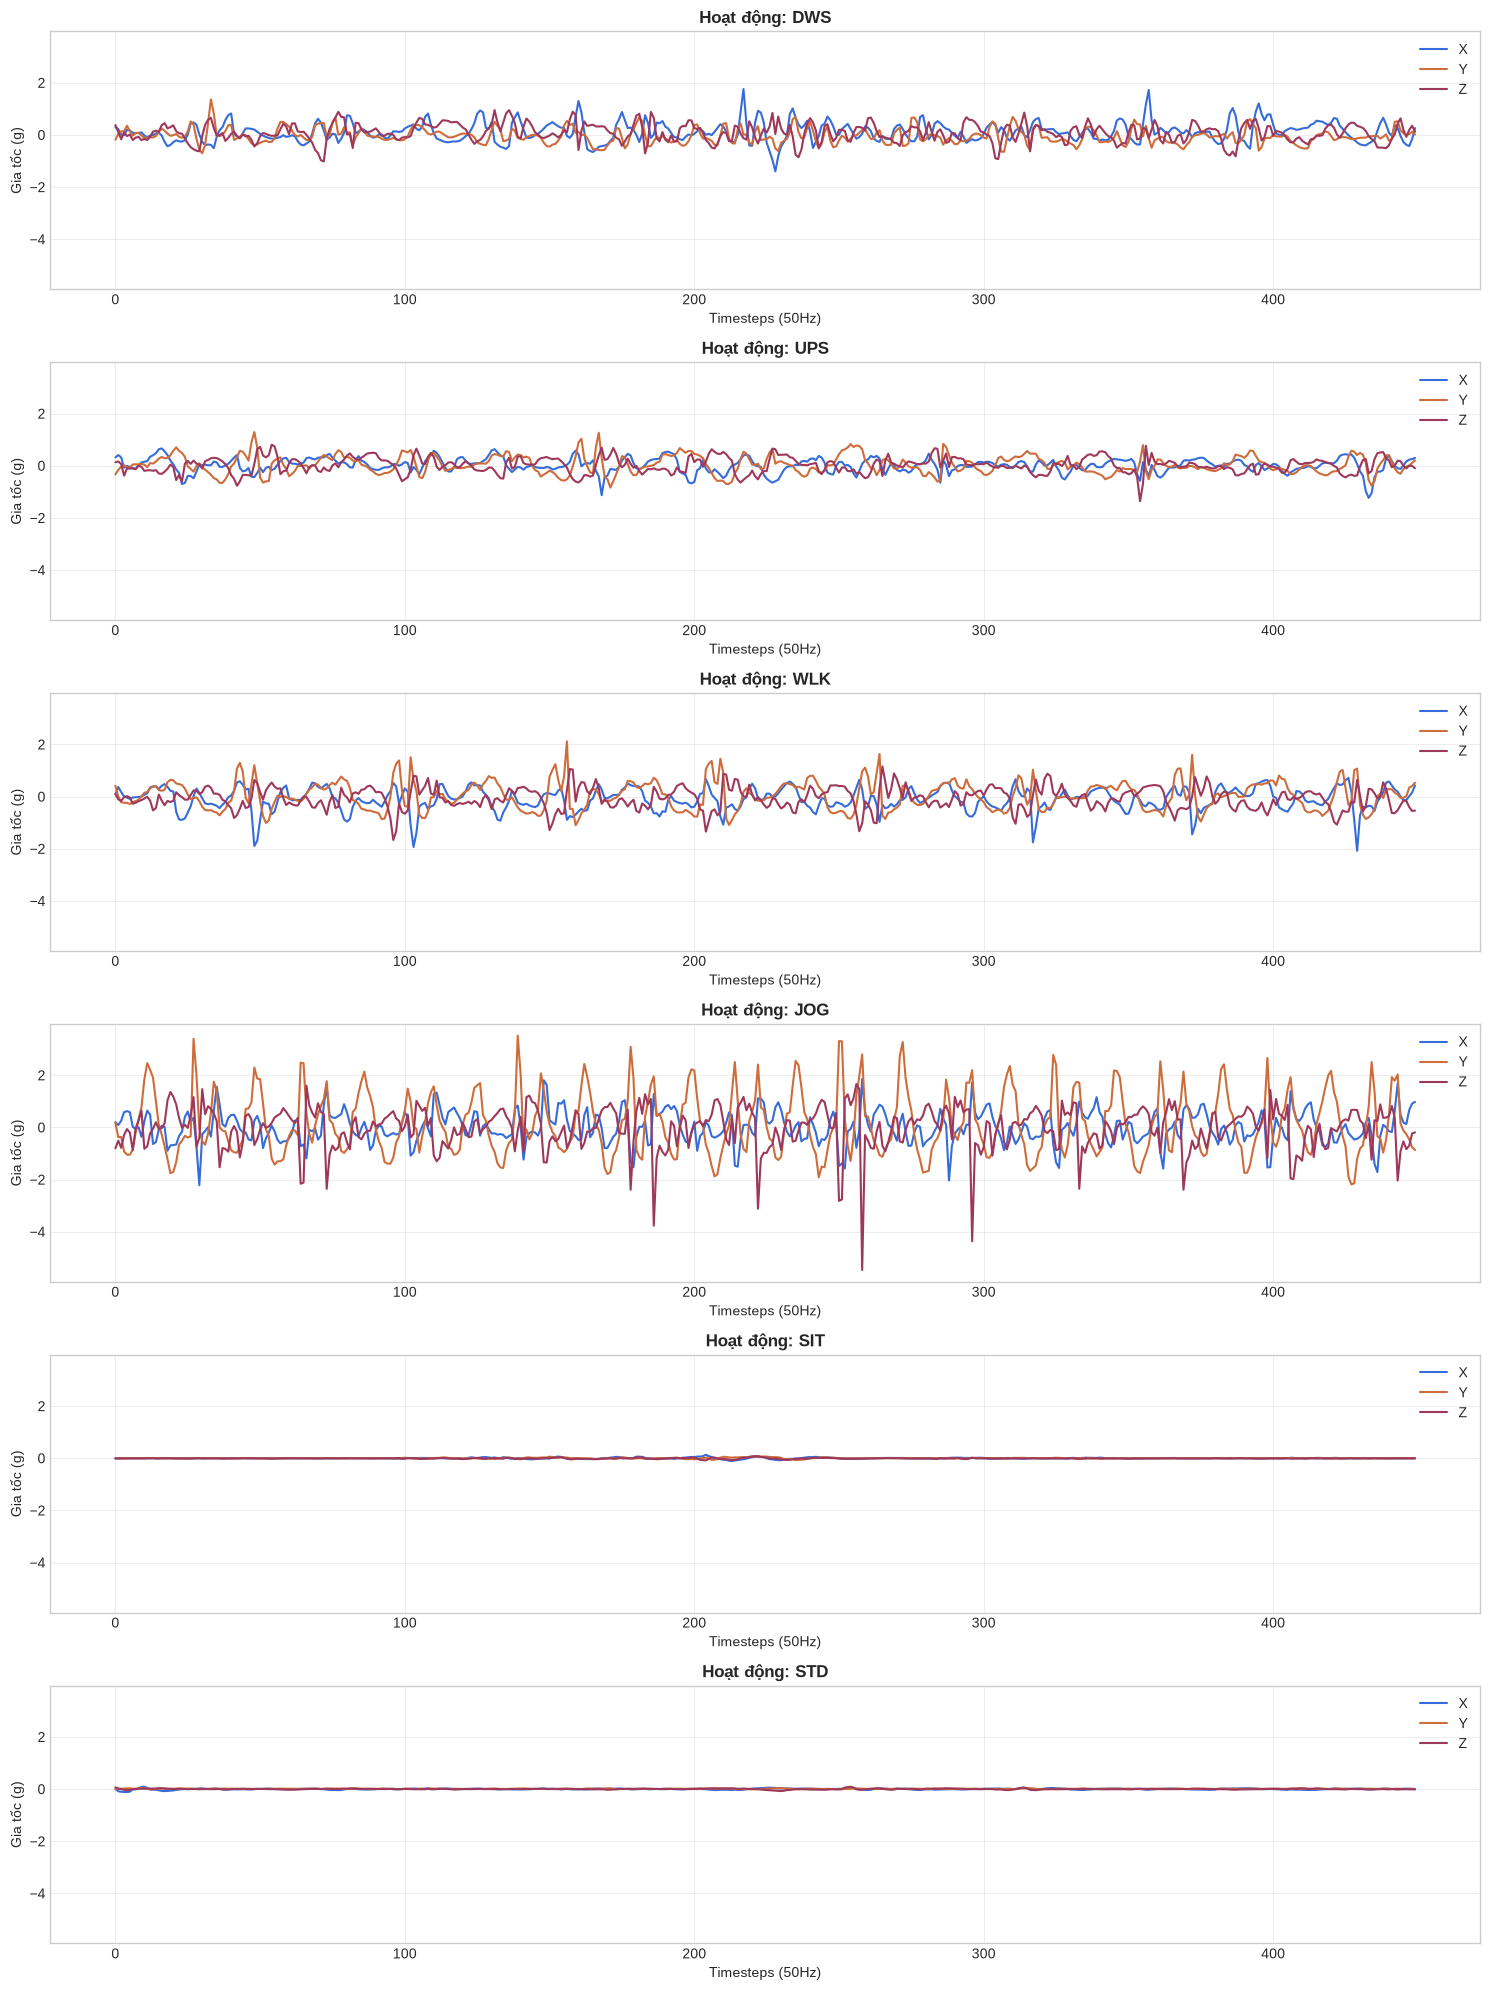

In [16]:
fig, axes = plt.subplots(6, 1, figsize=(15, 20), sharey=True)
axes = axes.flatten()

for idx, (act_code, rel_path) in enumerate(activities.items()):
    file_path = DATA_DIR_MOTION_SENSE / rel_path
    if file_path.exists():
        df_act = pd.read_csv(file_path)
        # Lấy 250 timesteps (5 giây) của 3 trục gia tốc
        acc_data = df_act[
            [
                "userAcceleration.x",
                "userAcceleration.y",
                "userAcceleration.z",
            ]
        ].iloc[00:450]

        axes[idx].plot(acc_data.values)
        axes[idx].set_title(f"Hoạt động: {act_code.upper()}", fontsize=12, fontweight="bold")

        axes[idx].set_xlabel("Timesteps (50Hz)")
        axes[idx].set_ylabel("Gia tốc (g)")
        axes[idx].grid(True)
        axes[idx].legend(["X","Y","Z"],loc = "upper right")

plt.tight_layout()
plt.show()